# **E-Commerce Customer Satisfaction Score Prediction using Artificial Neural Networks (ANN)**

**Project Type:** Deep Learning — Multiclass Classification  
**Contribution:** Individual  
**Primary target:** `CSAT Score`  
**Final deliverable:** One end-to-end notebook + saved deployment artifacts

> **Improved version:** This notebook replaces the earlier heavily class-weighted ANN approach.  
> The earlier run achieved only ~34% accuracy because full inverse-frequency class weights caused severe over-prediction of rare CSAT classes.  
> This version uses a clean train/validation/test design, richer but controlled features, a stronger text representation, and compares an accuracy-focused ANN against a softly balanced ANN.

# **Project Summary**

The objective of this project is to predict customer satisfaction (CSAT) scores for an e-commerce customer-support operation using an Artificial Neural Network (ANN). The raw data combines operational, categorical, timestamp, agent, product and customer-feedback information. The target is an ordinal five-level CSAT score, but the required ANN is implemented as a five-class classifier so that each score remains directly interpretable.

The workflow begins with data-quality checks and business-oriented feature engineering. Timestamps are converted into response-time, issue-age, survey-delay and time-of-day features. Highly skewed duration and price measures are log-transformed rather than blindly removing genuine operational extremes. Text feedback is represented using TF-IDF, while categorical features are safely one-hot encoded with infrequent-category handling. Agent hierarchy fields are retained in a controlled form because service quality can vary across operational teams.

The dataset is strongly imbalanced, with CSAT 5 representing the majority of records. A previous implementation applied full balanced class weights, which substantially improved attention to rare classes but reduced exact test accuracy to roughly 34%. This notebook therefore compares two ANN strategies: an accuracy-focused model trained on the natural class distribution, and a softly balanced model using tempered class weights. Validation data is used for model and prediction-rule selection; the test set is reserved for one final unbiased evaluation.

Evaluation includes exact accuracy, balanced accuracy, macro and weighted F1, quadratic weighted kappa, mean absolute error in CSAT points, and the percentage of predictions within ±1 CSAT point. This avoids presenting accuracy alone as sufficient evidence of model quality. A majority-class baseline is also reported so that an apparently high accuracy cannot be mistaken for real predictive value.

The final selected ANN, fitted preprocessing pipeline, target encoder and inference configuration are saved as deployment artifacts for the Flask demonstration. The notebook is designed to be executable from top to bottom in Google Colab or a local Jupyter/VS Code environment.

# **GitHub Link**
Replace the placeholder below before final submission:

`https://github.com/<YOUR_USERNAME>/<YOUR_REPOSITORY>`

# **Problem Statement**

Build an ANN-based model that predicts the customer **CSAT score (1–5)** from customer-support interactions and feedback, while identifying the operational factors associated with poor satisfaction. The model should be evaluated rigorously and packaged for a local Flask demonstration.

# ***Let's Begin!***

## **1. Environment, Libraries and Reproducibility**

In [1]:
# Core
from pathlib import Path
import json, os, random, warnings, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Statistics
from scipy.stats import kruskal, spearmanr

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, f1_score, cohen_kappa_score,
    mean_absolute_error
)

# Persistence
import joblib

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)
print("Random seed:", SEED)

TensorFlow: 2.21.0
Pandas: 3.0.5
Random seed: 42


## **2. Load and Understand the Dataset**

The loader first checks the current working directory for a CSV/XLSX file. If no dataset is found and the notebook is running in Colab, it opens the Colab upload widget.

In [2]:
def locate_dataset():
    preferred = [
        "eCommerce_Customer_support_data.csv",
        "ecommerce_customer_support_data.csv",
        "E-Commerce Customer Satisfaction.csv",
    ]
    for name in preferred:
        p = Path(name)
        if p.exists():
            return p

    candidates = []
    for pattern in ("*.csv", "*.xlsx", "*.xls"):
        candidates.extend(Path(".").glob(pattern))

    # Avoid accidentally loading model result exports if present.
    candidates = [
        p for p in candidates
        if not any(token in p.name.lower() for token in ["metric", "prediction", "importance", "report"])
    ]
    return sorted(candidates)[0] if candidates else None


DATA_PATH = locate_dataset()

if DATA_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No dataset was uploaded.")
        DATA_PATH = Path(next(iter(uploaded.keys())))
    except ImportError:
        raise FileNotFoundError(
            "Dataset not found. Place the project CSV/XLSX beside this notebook and rerun this cell."
        )

if DATA_PATH.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_excel(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Loaded: eCommerce_Customer_support_data.csv
Shape: (85907, 20)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Normalize column names

In [3]:
def normalize_col(col):
    col = str(col).strip().lower()
    for ch in [" ", "-", "/", "(", ")", "%", ".", ":"]:
        col = col.replace(ch, "_")
    while "__" in col:
        col = col.replace("__", "_")
    return col.strip("_")

df = df.copy()
df.columns = [normalize_col(c) for c in df.columns]

# Normalize expected target spelling.
target_aliases = [c for c in df.columns if c.replace("_", "") in {"csatscore", "csat"}]
if "csat_score" not in df.columns and target_aliases:
    df = df.rename(columns={target_aliases[0]: "csat_score"})

required_target = "csat_score"
if required_target not in df.columns:
    raise KeyError(f"Target '{required_target}' not found. Columns are: {list(df.columns)}")

print("Columns:")
print(df.columns.tolist())

Columns:
['unique_id', 'channel_name', 'category', 'sub_category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'customer_city', 'product_category', 'item_price', 'connected_handling_time', 'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift', 'csat_score']


### Data integrity summary

In [4]:
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Exact duplicate rows: {df.duplicated().sum():,}")

summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100),
    "unique": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(summary)

Rows: 85,907
Columns: 20
Exact duplicate rows: 0


,dtype,non_null,missing,missing_pct,unique
connected_handling_time,float64,242,85665,99.7183,211
customer_city,str,17079,68828,80.1192,1782
product_category,str,17196,68711,79.9830,9
item_price,float64,17206,68701,79.9714,2789
order_date_time,str,17214,68693,79.9621,13766
customer_remarks,str,28742,57165,66.5429,18231
order_id,str,67675,18232,21.2230,67675
unique_id,str,85907,0,0.0000,85907
sub_category,str,85907,0,0.0000,57
category,str,85907,0,0.0000,12


## **3. Data Cleaning and Feature Engineering**

The feature builder is deliberately deployment-reproducible: the same function can later be copied into `app.py`.

Key improvements in this version:
- keeps valid operational extremes but uses `log1p` transforms for highly skewed numeric variables;
- adds cyclical hour features;
- retains agent hierarchy fields in a controlled way instead of dropping all of them;
- adds missingness indicators for very sparse business fields;
- avoids target-derived features, preventing leakage.

In [5]:
df_clean = df.drop_duplicates().copy()
df_clean["csat_score"] = pd.to_numeric(df_clean["csat_score"], errors="coerce")
df_clean = df_clean[df_clean["csat_score"].isin([1, 2, 3, 4, 5])].reset_index(drop=True)

print("Clean shape:", df_clean.shape)
print("Target distribution:")
display(df_clean["csat_score"].value_counts().sort_index().to_frame("count"))

Clean shape: (85907, 20)
Target distribution:


,count
csat_score,
1,11230
2,1283
3,2558
4,11219
5,59617


In [6]:
def parse_datetime_safe(series):
    try:
        return pd.to_datetime(series, errors="coerce", format="mixed")
    except TypeError:
        return pd.to_datetime(series, errors="coerce")


def safe_log1p(series):
    s = pd.to_numeric(series, errors="coerce")
    s = s.where(s >= 0)
    return np.log1p(s)


def build_features(frame):
    out = frame.copy()

    # Raw numerics
    for col in ["item_price", "connected_handling_time"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    # Datetime parsing
    datetime_cols = [
        "order_date_time", "issue_reported_at",
        "issue_responded", "survey_response_date"
    ]
    for col in datetime_cols:
        if col in out.columns:
            out[col] = parse_datetime_safe(out[col])

    # Operational durations
    if {"issue_reported_at", "issue_responded"}.issubset(out.columns):
        response = (out["issue_responded"] - out["issue_reported_at"]).dt.total_seconds() / 60
        out["response_time_minutes"] = response.where(response >= 0)

    if {"order_date_time", "issue_reported_at"}.issubset(out.columns):
        age = (out["issue_reported_at"] - out["order_date_time"]).dt.total_seconds() / 3600
        out["order_to_issue_hours"] = age.where(age >= 0)

    if {"issue_responded", "survey_response_date"}.issubset(out.columns):
        delay = (out["survey_response_date"] - out["issue_responded"]).dt.total_seconds() / 3600
        out["survey_delay_hours"] = delay.where(delay >= 0)

    # Time-of-day features
    if "issue_reported_at" in out.columns:
        hour = out["issue_reported_at"].dt.hour
        out["issue_hour"] = hour
        out["issue_day_name"] = out["issue_reported_at"].dt.day_name()
        out["is_weekend"] = out["issue_reported_at"].dt.dayofweek.isin([5, 6]).astype(float)
        out["issue_hour_sin"] = np.sin(2 * np.pi * hour / 24)
        out["issue_hour_cos"] = np.cos(2 * np.pi * hour / 24)
        out["issue_hour_bucket"] = pd.cut(
            hour,
            bins=[-1, 5, 11, 17, 21, 23],
            labels=["Late Night", "Morning", "Afternoon", "Evening", "Night"]
        ).astype("object")

    # Text presence/length features
    if "customer_remarks" in out.columns:
        remarks = out["customer_remarks"].fillna("").astype(str)
        out["remarks_length"] = remarks.str.len()
        out["remarks_word_count"] = remarks.str.split().str.len()
        out["has_customer_remarks"] = remarks.str.strip().ne("").astype(float)

    # Missingness itself can carry operational information.
    sparse_business_cols = [
        "item_price", "connected_handling_time", "customer_city",
        "product_category", "order_date_time", "customer_remarks"
    ]
    for col in sparse_business_cols:
        if col in out.columns:
            out[f"{col}_missing"] = out[col].isna().astype(float)

    # Smooth highly skewed numeric variables without deleting legitimate cases.
    for col in [
        "item_price", "connected_handling_time", "response_time_minutes",
        "order_to_issue_hours", "survey_delay_hours",
        "remarks_length", "remarks_word_count"
    ]:
        if col in out.columns:
            out[f"{col}_log1p"] = safe_log1p(out[col])

    return out


df_feat = build_features(df_clean)
print("Feature-engineered shape:", df_feat.shape)
print("New features:")
print([c for c in df_feat.columns if c not in df_clean.columns])

Feature-engineered shape: (85907, 45)
New features:
['response_time_minutes', 'order_to_issue_hours', 'survey_delay_hours', 'issue_hour', 'issue_day_name', 'is_weekend', 'issue_hour_sin', 'issue_hour_cos', 'issue_hour_bucket', 'remarks_length', 'remarks_word_count', 'has_customer_remarks', 'item_price_missing', 'connected_handling_time_missing', 'customer_city_missing', 'product_category_missing', 'order_date_time_missing', 'customer_remarks_missing', 'item_price_log1p', 'connected_handling_time_log1p', 'response_time_minutes_log1p', 'order_to_issue_hours_log1p', 'survey_delay_hours_log1p', 'remarks_length_log1p', 'remarks_word_count_log1p']


## **4. Focused EDA — 8 Meaningful Charts**

The earlier notebook contained many repetitive univariate plots. This version keeps only eight charts that directly support the modeling or the business story.

### **EDA Chart 1 — CSAT distribution and class imbalance**

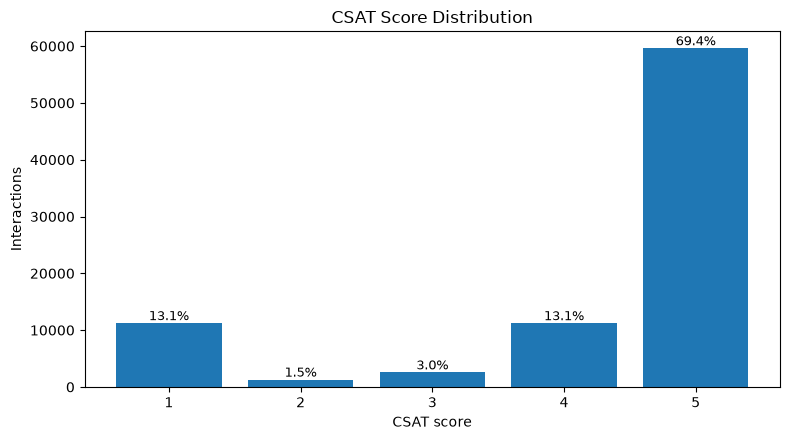

Majority-class share: 0.694


In [7]:
counts = df_feat["csat_score"].value_counts().sort_index()
shares = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.index.astype(str), counts.values)
ax.set_title("CSAT Score Distribution")
ax.set_xlabel("CSAT score")
ax.set_ylabel("Interactions")
for bar, pct in zip(bars, shares.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{pct:.1f}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("Majority-class share:", round(shares.max()/100, 4))

**Why this chart?** It reveals the most important modeling constraint: severe class imbalance.  
**Business/model insight:** A model can obtain a deceptively high accuracy simply by predicting the majority score, so accuracy must be compared against a majority baseline and supplemented with Macro F1 and ordinal metrics.

### **EDA Chart 2 — Missing-data concentration**

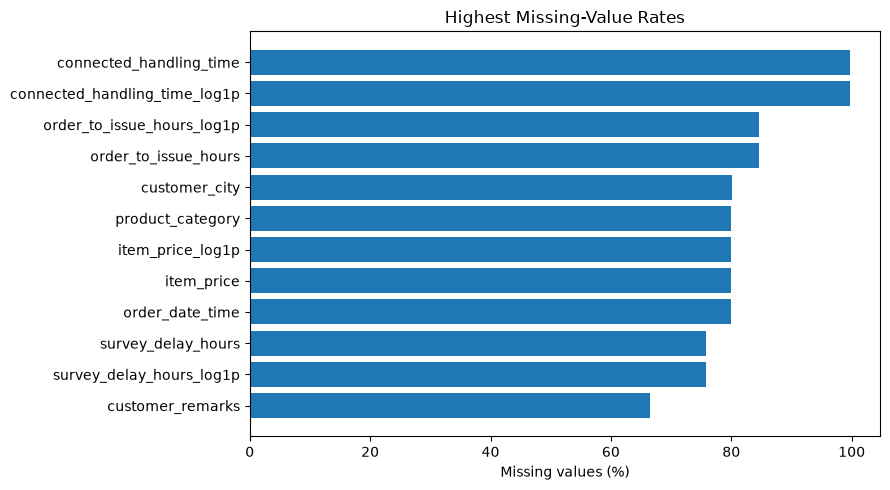

In [8]:
missing = df_feat.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0].head(12).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(missing.index, missing.values)
ax.set_title("Highest Missing-Value Rates")
ax.set_xlabel("Missing values (%)")
plt.tight_layout()
plt.show()

**Insight:** Several commerce and customer fields are sparse, so dropping incomplete rows would destroy a large part of the dataset. Imputation plus explicit missingness indicators is safer.

### **EDA Chart 3 — Channel volume and mean CSAT**

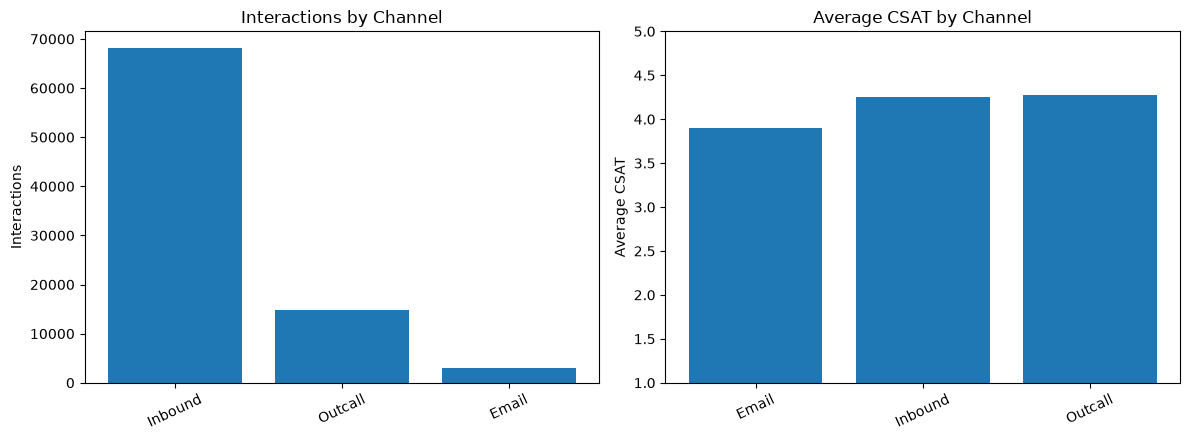

,count,mean
channel_name,,
Inbound,68142,4.2510
Outcall,14742,4.2700
Email,3023,3.8990


In [9]:
if "channel_name" in df_feat.columns:
    channel_stats = df_feat.groupby("channel_name")["csat_score"].agg(["count", "mean"]).sort_values("count", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(channel_stats.index.astype(str), channel_stats["count"])
    axes[0].set_title("Interactions by Channel")
    axes[0].tick_params(axis="x", rotation=25)
    axes[0].set_ylabel("Interactions")

    ordered = channel_stats.sort_values("mean")
    axes[1].bar(ordered.index.astype(str), ordered["mean"])
    axes[1].set_title("Average CSAT by Channel")
    axes[1].tick_params(axis="x", rotation=25)
    axes[1].set_ylim(1, 5)
    axes[1].set_ylabel("Average CSAT")
    plt.tight_layout()
    plt.show()

    display(channel_stats.round(3))

### **EDA Chart 4 — Major interaction categories: volume vs satisfaction**

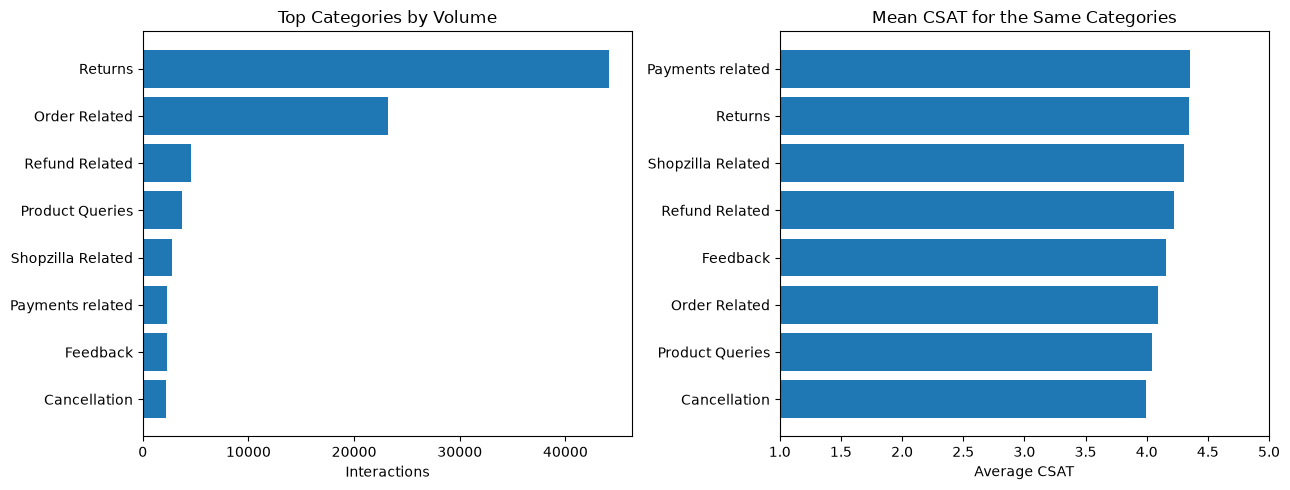

In [10]:
if "category" in df_feat.columns:
    cat_stats = df_feat.groupby("category")["csat_score"].agg(["count", "mean"])
    top_categories = cat_stats.nlargest(8, "count").index
    view = cat_stats.loc[top_categories].sort_values("count")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].barh(view.index.astype(str), view["count"])
    axes[0].set_title("Top Categories by Volume")
    axes[0].set_xlabel("Interactions")

    mean_view = cat_stats.loc[top_categories].sort_values("mean")
    axes[1].barh(mean_view.index.astype(str), mean_view["mean"])
    axes[1].set_title("Mean CSAT for the Same Categories")
    axes[1].set_xlim(1, 5)
    axes[1].set_xlabel("Average CSAT")
    plt.tight_layout()
    plt.show()

### **EDA Chart 5 — Agent shift and tenure effects**

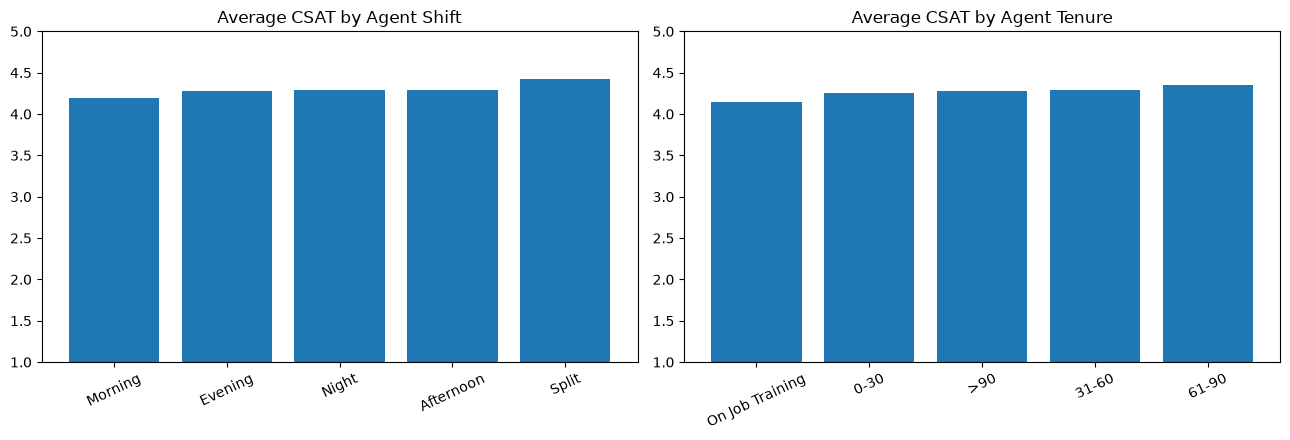

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

if "agent_shift" in df_feat.columns:
    shift = df_feat.groupby("agent_shift")["csat_score"].agg(["mean", "count"]).sort_values("mean")
    axes[0].bar(shift.index.astype(str), shift["mean"])
    axes[0].set_ylim(1, 5)
    axes[0].set_title("Average CSAT by Agent Shift")
    axes[0].tick_params(axis="x", rotation=25)

if "tenure_bucket" in df_feat.columns:
    tenure = df_feat.groupby("tenure_bucket")["csat_score"].agg(["mean", "count"]).sort_values("mean")
    axes[1].bar(tenure.index.astype(str), tenure["mean"])
    axes[1].set_ylim(1, 5)
    axes[1].set_title("Average CSAT by Agent Tenure")
    axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### **EDA Chart 6 — Response time vs CSAT**

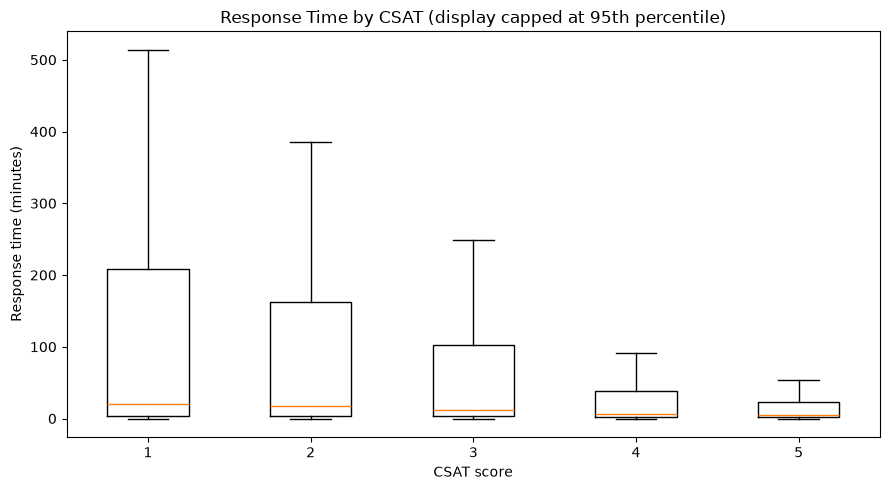

Spearman rho=-0.1820, p=0


In [13]:
if "response_time_minutes" in df_feat.columns:
    temp = df_feat[["csat_score", "response_time_minutes"]].dropna().copy()
    upper = temp["response_time_minutes"].quantile(0.95)
    temp["response_time_display"] = temp["response_time_minutes"].clip(upper=upper)

    groups = [
        temp.loc[temp["csat_score"].eq(score), "response_time_display"].values
        for score in sorted(temp["csat_score"].unique())
    ]
    labels = [str(x) for x in sorted(temp["csat_score"].unique())]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(groups, tick_labels=labels, showfliers=False)
    ax.set_title("Response Time by CSAT (display capped at 95th percentile)")
    ax.set_xlabel("CSAT score")
    ax.set_ylabel("Response time (minutes)")
    plt.tight_layout()
    plt.show()

    rho, p = spearmanr(temp["response_time_minutes"], temp["csat_score"])
    print(f"Spearman rho={rho:.4f}, p={p:.3g}")

**Insight:** This chart directly tests whether slower service is associated with lower satisfaction while preventing a few extreme response times from dominating the visual scale.

### **EDA Chart 7 — Mean CSAT by issue hour**

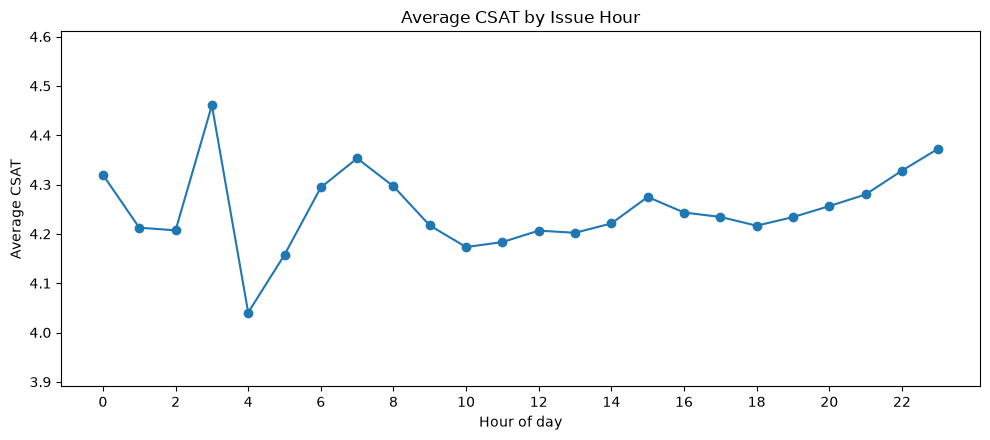

In [14]:
if "issue_hour" in df_feat.columns:
    hourly = df_feat.groupby("issue_hour")["csat_score"].agg(["mean", "count"]).reindex(range(24))

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(hourly.index, hourly["mean"], marker="o")
    ax.set_title("Average CSAT by Issue Hour")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Average CSAT")
    ax.set_xticks(range(0, 24, 2))
    ax.set_ylim(max(1, hourly["mean"].min() - 0.15), min(5, hourly["mean"].max() + 0.15))
    plt.tight_layout()
    plt.show()

### **EDA Chart 8 — Response-speed buckets and CSAT**

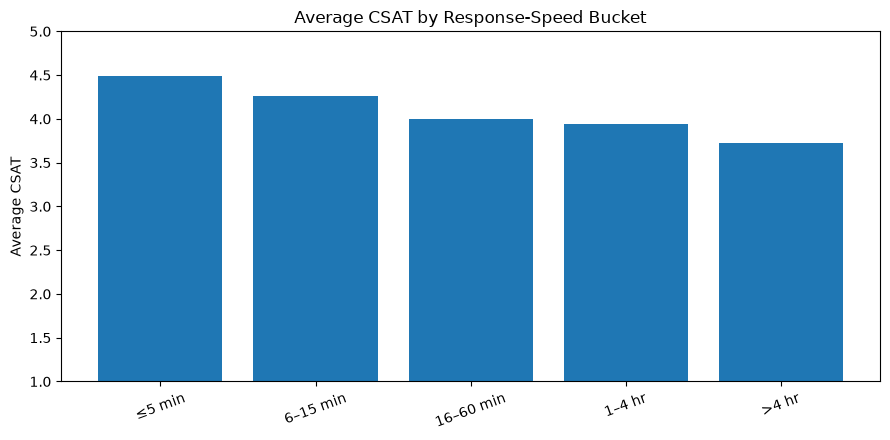

,mean,count
response_bucket,,
≤5 min,4.4840,40460
6–15 min,4.2580,13864
16–60 min,3.9940,10290
1–4 hr,3.9440,7257
>4 hr,3.7210,10315


In [15]:
if "response_time_minutes" in df_feat.columns:
    temp = df_feat[["response_time_minutes", "csat_score"]].dropna().copy()
    temp["response_bucket"] = pd.cut(
        temp["response_time_minutes"],
        bins=[-0.001, 5, 15, 60, 240, np.inf],
        labels=["≤5 min", "6–15 min", "16–60 min", "1–4 hr", ">4 hr"]
    )
    speed = temp.groupby("response_bucket", observed=True)["csat_score"].agg(["mean", "count"])

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(speed.index.astype(str), speed["mean"])
    ax.set_ylim(1, 5)
    ax.set_title("Average CSAT by Response-Speed Bucket")
    ax.set_ylabel("Average CSAT")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

    display(speed.round(3))

## **5. Hypothesis Testing**

Three tests are retained because they support the business story rather than merely increasing notebook length.

In [16]:
# H1: CSAT differs across channels.
if "channel_name" in df_feat.columns:
    groups = [g["csat_score"].values for _, g in df_feat.groupby("channel_name") if len(g) >= 5]
    h, p = kruskal(*groups)
    print(f"H1 — Channel vs CSAT: H={h:.4f}, p={p:.4g}")
    print("Decision:", "Reject H0" if p < 0.05 else "Fail to reject H0")

H1 — Channel vs CSAT: H=151.1141, p=1.535e-33
Decision: Reject H0


In [17]:
# H2: CSAT differs across agent shifts.
if "agent_shift" in df_feat.columns:
    groups = [g["csat_score"].values for _, g in df_feat.groupby("agent_shift") if len(g) >= 5]
    h, p = kruskal(*groups)
    print(f"H2 — Agent shift vs CSAT: H={h:.4f}, p={p:.4g}")
    print("Decision:", "Reject H0" if p < 0.05 else "Fail to reject H0")

H2 — Agent shift vs CSAT: H=151.5800, p=9.335e-32
Decision: Reject H0


In [18]:
# H3: Response time has a monotonic relationship with CSAT.
if "response_time_minutes" in df_feat.columns:
    temp = df_feat[["response_time_minutes", "csat_score"]].dropna()
    rho, p = spearmanr(temp["response_time_minutes"], temp["csat_score"])
    print(f"H3 — Response time vs CSAT: rho={rho:.4f}, p={p:.4g}")
    print("Decision:", "Reject H0" if p < 0.05 else "Fail to reject H0")

H3 — Response time vs CSAT: rho=-0.1820, p=0
Decision: Reject H0


## **6. Final Feature Set and Leakage-Safe Split**

### Why this is different from the earlier notebook

The previous notebook:
1. dropped all agent hierarchy fields;
2. used only 300 TF-IDF features;
3. applied full balanced class weights;
4. selected the final model after looking at test performance.

This version:
- keeps `manager`, `supervisor`, and `agent_name` with controlled one-hot cardinality;
- increases TF-IDF capacity moderately;
- creates separate train, validation and test sets;
- compares natural-distribution and softly balanced ANN training;
- selects the model/prediction rule on **validation data only**.

In [19]:
# Deployment-safe feature groups.
candidate_numeric = [
    "item_price_log1p",
    "connected_handling_time_log1p",
    "response_time_minutes_log1p",
    "order_to_issue_hours_log1p",
    "survey_delay_hours_log1p",
    "issue_hour_sin",
    "issue_hour_cos",
    "is_weekend",
    "remarks_length_log1p",
    "remarks_word_count_log1p",
    "has_customer_remarks",
    "item_price_missing",
    "connected_handling_time_missing",
    "customer_city_missing",
    "product_category_missing",
    "order_date_time_missing",
    "customer_remarks_missing",
]

candidate_categorical = [
    "channel_name",
    "category",
    "sub_category",
    "product_category",
    "tenure_bucket",
    "agent_shift",
    "issue_day_name",
    "issue_hour_bucket",
    "manager",
    "supervisor",
    "agent_name",
]

numeric_features = [c for c in candidate_numeric if c in df_feat.columns]
categorical_features = [c for c in candidate_categorical if c in df_feat.columns]
text_feature = "customer_remarks" if "customer_remarks" in df_feat.columns else None

model_features = numeric_features + categorical_features + ([text_feature] if text_feature else [])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Text feature:", text_feature)
print("Total raw model features:", len(model_features))

Numeric features: ['item_price_log1p', 'connected_handling_time_log1p', 'response_time_minutes_log1p', 'order_to_issue_hours_log1p', 'survey_delay_hours_log1p', 'issue_hour_sin', 'issue_hour_cos', 'is_weekend', 'remarks_length_log1p', 'remarks_word_count_log1p', 'has_customer_remarks', 'item_price_missing', 'connected_handling_time_missing', 'customer_city_missing', 'product_category_missing', 'order_date_time_missing', 'customer_remarks_missing']
Categorical features: ['channel_name', 'category', 'sub_category', 'product_category', 'tenure_bucket', 'agent_shift', 'issue_day_name', 'issue_hour_bucket', 'manager', 'supervisor', 'agent_name']
Text feature: customer_remarks
Total raw model features: 29


In [20]:
model_df = df_feat[model_features + ["csat_score"]].copy()

if text_feature:
    model_df[text_feature] = (
        model_df[text_feature]
        .fillna("no_customer_remarks")
        .astype(str)
        .replace(r"^\s*$", "no_customer_remarks", regex=True)
    )

X = model_df[model_features].copy()
y_score = model_df["csat_score"].astype(int).to_numpy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_score)

print("Target mapping:")
for i, score in enumerate(label_encoder.classes_):
    print(f"  class {i} -> CSAT {score}")

Target mapping:
  class 0 -> CSAT 1
  class 1 -> CSAT 2
  class 2 -> CSAT 3
  class 3 -> CSAT 4
  class 4 -> CSAT 5


In [21]:
# 70% train / 15% validation / 15% test, all stratified.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, pd.Series(y_train).value_counts(normalize=True).sort_index().round(4).to_dict())
print("Val  :", X_val.shape, pd.Series(y_val).value_counts(normalize=True).sort_index().round(4).to_dict())
print("Test :", X_test.shape, pd.Series(y_test).value_counts(normalize=True).sort_index().round(4).to_dict())

Train: (60134, 29) {0: 0.1307, 1: 0.0149, 2: 0.0298, 3: 0.1306, 4: 0.694}
Val  : (12886, 29) {0: 0.1307, 1: 0.015, 2: 0.0297, 3: 0.1306, 4: 0.694}
Test : (12887, 29) {0: 0.1308, 1: 0.0149, 2: 0.0298, 3: 0.1306, 4: 0.694}


### Preprocessing pipeline

In [22]:
def make_one_hot_encoder():
    # "infrequent_if_exist" keeps high-cardinality fields manageable and safely handles unseen values.
    kwargs = dict(
        handle_unknown="infrequent_if_exist",
        min_frequency=10,
        max_categories=100
    )
    try:
        return OneHotEncoder(**kwargs, sparse_output=False, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(**kwargs, sparse=False, dtype=np.float32)


transformers = []

if numeric_features:
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    transformers.append(("num", numeric_pipeline, numeric_features))

if categorical_features:
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder())
    ])
    transformers.append(("cat", categorical_pipeline, categorical_features))

if text_feature:
    text_vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        stop_words="english",
        ngram_range=(1, 2),
        max_features=600,
        min_df=3,
        max_df=0.995,
        sublinear_tf=True,
        dtype=np.float32
    )
    transformers.append(("text", text_vectorizer, text_feature))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.0
)

X_train_p = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_p = preprocessor.transform(X_val).astype(np.float32)
X_test_p = preprocessor.transform(X_test).astype(np.float32)

print("Processed shapes:")
print("  train:", X_train_p.shape)
print("  val  :", X_val_p.shape)
print("  test :", X_test_p.shape)
print("Train matrix approx MB:", round(X_train_p.nbytes / 1024**2, 2))

Processed shapes:
  train: (60134, 861)
  val  : (12886, 861)
  test : (12887, 861)
Train matrix approx MB: 197.51


## **7. Imbalance Strategy and Benchmarks**

The old notebook used the full balanced weights directly. On the recorded run, that produced weights of approximately:

- CSAT 1: 1.53
- CSAT 2: 13.38
- CSAT 3: 6.72
- CSAT 4: 1.53
- CSAT 5: 0.29

Those weights strongly distort the natural probability distribution. Here we keep two candidates:

1. **Accuracy-focused ANN** — no class weights.
2. **Soft-balanced ANN** — tempered weights using the square root of the balanced weights, normalized and clipped.

The validation set decides which inference strategy is retained.

In [23]:
# Majority-class baseline: every real model should be compared against this.
majority_class = int(pd.Series(y_train).value_counts().idxmax())
majority_val_pred = np.full_like(y_val, majority_class)
majority_test_pred = np.full_like(y_test, majority_class)

print("Majority class:", label_encoder.inverse_transform([majority_class])[0])
print("Majority validation accuracy:", round(accuracy_score(y_val, majority_val_pred), 4))
print("Majority test accuracy:", round(accuracy_score(y_test, majority_test_pred), 4))

Majority class: 5
Majority validation accuracy: 0.694
Majority test accuracy: 0.694


In [24]:
classes_present = np.unique(y_train)
balanced = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train
)
balanced_weights = {int(c): float(w) for c, w in zip(classes_present, balanced)}

# Temper extreme minority weights rather than completely flattening the class prior.
soft_raw = {c: math.sqrt(w) for c, w in balanced_weights.items()}

# Normalize to an average sample weight of ~1 on the training distribution.
train_freq = pd.Series(y_train).value_counts(normalize=True).to_dict()
normalizer = sum(train_freq[c] * soft_raw[c] for c in soft_raw)
soft_weights = {
    c: float(np.clip(soft_raw[c] / normalizer, 0.50, 3.50))
    for c in soft_raw
}

weights_table = pd.DataFrame({
    "CSAT": label_encoder.inverse_transform(classes_present),
    "Full balanced weight": [balanced_weights[int(c)] for c in classes_present],
    "Soft weight used": [soft_weights[int(c)] for c in classes_present]
})
display(weights_table.round(3))

,CSAT,Full balanced weight,Soft weight used
0,1,1.5300,1.4940
1,2,13.3930,3.5000
2,3,6.7150,3.1310
3,4,1.5310,1.4950
4,5,0.2880,0.6490


## **8. ANN Modeling**

Both candidates use the same architecture so that the imbalance strategy—not arbitrary architecture changes—is the main experimental difference.

In [25]:
input_dim = X_train_p.shape[1]
num_classes = len(label_encoder.classes_)

def build_ann(input_dim, num_classes, seed=SEED):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(5e-5)),
        layers.BatchNormalization(),
        layers.Dropout(0.18),

        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(5e-5)),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.10),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=8e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=6,
            min_delta=0.0005,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

### Model A — Accuracy-focused ANN

In [26]:
accuracy_model = build_ann(input_dim, num_classes)

accuracy_history = accuracy_model.fit(
    X_train_p,
    y_train,
    validation_data=(X_val_p, y_val),
    epochs=45,
    batch_size=256,
    callbacks=make_callbacks(),
    verbose=1
)


Epoch 1/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6296 - loss: 1.1453 - val_accuracy: 0.7039 - val_loss: 0.9551 - learning_rate: 8.0000e-04
Epoch 2/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7111 - loss: 0.9261 - val_accuracy: 0.7174 - val_loss: 0.8873 - learning_rate: 8.0000e-04
Epoch 3/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7210 - loss: 0.8951 - val_accuracy: 0.7205 - val_loss: 0.8803 - learning_rate: 8.0000e-04
Epoch 4/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7244 - loss: 0.8747 - val_accuracy: 0.7220 - val_loss: 0.8760 - learning_rate: 8.0000e-04
Epoch 5/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7261 - loss: 0.8627 - val_accuracy: 0.7231 - val_loss: 0.8780 - learning_rate: 8.0000e-04
Epoch 6/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7290 - loss: 0.8488 - val_accuracy: 0.7222 - val_loss: 0.8785 - learning_rate: 8.0000e-04
Epoch 7/45
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accu

### Model B — Soft-balanced ANN

In [27]:
soft_model = build_ann(input_dim, num_classes, seed=SEED + 1)

soft_history = soft_model.fit(
    X_train_p,
    y_train,
    validation_data=(X_val_p, y_val),
    epochs=45,
    batch_size=256,
    class_weight=soft_weights,
    callbacks=make_callbacks(),
    verbose=1
)

Epoch 1/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6016 - loss: 1.4376 - val_accuracy: 0.7116 - val_loss: 1.1734 - learning_rate: 8.0000e-04
Epoch 2/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6730 - loss: 1.2989 - val_accuracy: 0.7100 - val_loss: 1.0508 - learning_rate: 8.0000e-04
Epoch 3/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6926 - loss: 1.2585 - val_accuracy: 0.7066 - val_loss: 1.0238 - learning_rate: 8.0000e-04
Epoch 4/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7026 - loss: 1.2366 - val_accuracy: 0.7088 - val_loss: 1.0155 - learning_rate: 8.0000e-04
Epoch 5/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7059 - loss: 1.2172 - val_accuracy: 0.7070 - val_loss: 1.0171 - learning_rate: 8.0000e-04
Epoch 6/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7094 - loss: 1.1997 - val_accuracy: 0.7087 - val_loss: 1.0074 - learning_rate: 8.0000e-04
Epoch 7/45
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy

## **9. Validation-Based Model Selection**

For a class-weighted softmax model, the learned probabilities reflect the reweighted training objective. Therefore the notebook evaluates both:
- direct argmax probabilities;
- a simple prior correction that divides each class probability by its training weight before renormalizing.

No test labels are used here.

In [28]:
def predict_proba(model, Xp):
    return model.predict(Xp, verbose=0)

def normalize_rows(a):
    s = a.sum(axis=1, keepdims=True)
    return a / np.clip(s, 1e-12, None)

def prior_correct(probabilities, weight_dict):
    divisors = np.array([weight_dict.get(i, 1.0) for i in range(probabilities.shape[1])], dtype=np.float32)
    corrected = probabilities / divisors.reshape(1, -1)
    return normalize_rows(corrected)

def metrics_from_pred(y_true_idx, pred_idx):
    y_true_score = label_encoder.inverse_transform(np.asarray(y_true_idx).astype(int))
    y_pred_score = label_encoder.inverse_transform(np.asarray(pred_idx).astype(int))

    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true_idx, pred_idx, average="macro", zero_division=0
    )
    _, _, f_weighted, _ = precision_recall_fscore_support(
        y_true_idx, pred_idx, average="weighted", zero_division=0
    )

    return {
        "Accuracy": accuracy_score(y_true_idx, pred_idx),
        "Balanced Accuracy": balanced_accuracy_score(y_true_idx, pred_idx),
        "Macro F1": f_macro,
        "Weighted F1": f_weighted,
        "Quadratic Kappa": cohen_kappa_score(y_true_score, y_pred_score, weights="quadratic"),
        "CSAT MAE": mean_absolute_error(y_true_score, y_pred_score),
        "Within ±1": np.mean(np.abs(y_true_score - y_pred_score) <= 1)
    }


accuracy_val_probs = predict_proba(accuracy_model, X_val_p)
soft_val_probs = predict_proba(soft_model, X_val_p)

validation_candidates = {
    "Accuracy ANN": {
        "model": accuracy_model,
        "probs": accuracy_val_probs,
        "pred": accuracy_val_probs.argmax(axis=1),
        "correction": np.ones(num_classes, dtype=np.float32)
    },
    "Soft-balanced ANN": {
        "model": soft_model,
        "probs": soft_val_probs,
        "pred": soft_val_probs.argmax(axis=1),
        "correction": np.ones(num_classes, dtype=np.float32)
    },
    "Soft-balanced ANN + prior correction": {
        "model": soft_model,
        "probs": prior_correct(soft_val_probs, soft_weights),
        "pred": prior_correct(soft_val_probs, soft_weights).argmax(axis=1),
        "correction": np.array([soft_weights[i] for i in range(num_classes)], dtype=np.float32)
    }
}

rows = []
for name, item in validation_candidates.items():
    rows.append({"Candidate": name, **metrics_from_pred(y_val, item["pred"])})

validation_results = pd.DataFrame(rows).set_index("Candidate").sort_values("Accuracy", ascending=False)
display(validation_results.round(4))

,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Quadratic Kappa,CSAT MAE,Within ±1
Candidate,,,,,,,
Accuracy ANN,0.7231,0.2644,0.2562,0.6384,0.3639,0.6464,0.8512
Soft-balanced ANN,0.7116,0.2503,0.2408,0.6245,0.2936,0.6895,0.8401
Soft-balanced ANN + prior correction,0.6969,0.2055,0.1752,0.5769,0.0394,0.7448,0.8279


### **Model Chart 1 — Validation accuracy and Macro F1**

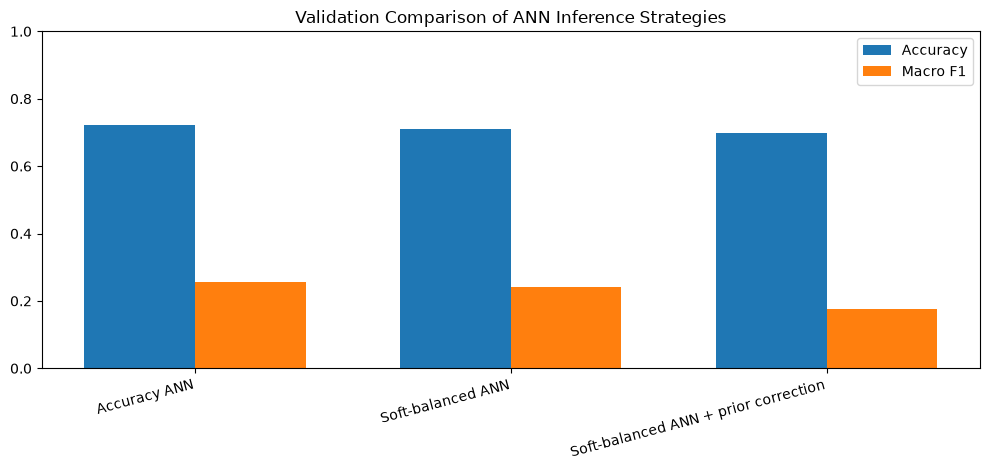

In [29]:
plot_df = validation_results[["Accuracy", "Macro F1"]].copy()

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(plot_df))
width = 0.35
ax.bar(x - width/2, plot_df["Accuracy"], width, label="Accuracy")
ax.bar(x + width/2, plot_df["Macro F1"], width, label="Macro F1")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_title("Validation Comparison of ANN Inference Strategies")
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
# Accuracy is the primary optimization target requested for this revision.
# Macro F1 remains visible as a guardrail.
best_candidate_name = validation_results["Accuracy"].idxmax()
best_candidate = validation_candidates[best_candidate_name]

final_model = best_candidate["model"]
probability_divisor = best_candidate["correction"]

print("Selected on validation data:", best_candidate_name)
print("Validation metrics:")
display(validation_results.loc[[best_candidate_name]].round(4))

majority_val_acc = accuracy_score(y_val, majority_val_pred)
best_val_acc = validation_results.loc[best_candidate_name, "Accuracy"]
if best_val_acc <= majority_val_acc:
    print(
        "\nWARNING: The selected ANN does not beat the majority-class baseline on validation accuracy. "
        "Do not claim accuracy improvement without reporting this fact."
    )
else:
    print(f"\nANN improvement over majority validation baseline: {best_val_acc - majority_val_acc:.4f}")

Selected on validation data: Accuracy ANN
Validation metrics:


,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Quadratic Kappa,CSAT MAE,Within ±1
Candidate,,,,,,,
Accuracy ANN,0.7231,0.2644,0.2562,0.6384,0.3639,0.6464,0.8512



ANN improvement over majority validation baseline: 0.0291


## **10. Final Test Evaluation**

Only after the validation choice is locked do we evaluate the test set.

In [31]:
test_probs_raw = predict_proba(final_model, X_test_p)

if np.allclose(probability_divisor, 1.0):
    final_test_probs = test_probs_raw
else:
    final_test_probs = normalize_rows(test_probs_raw / probability_divisor.reshape(1, -1))

final_test_pred = final_test_probs.argmax(axis=1)
final_test_metrics = metrics_from_pred(y_test, final_test_pred)

majority_metrics = metrics_from_pred(y_test, majority_test_pred)

test_comparison = pd.DataFrame(
    [majority_metrics, final_test_metrics],
    index=["Majority baseline", best_candidate_name]
)

display(test_comparison.round(4))

,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Quadratic Kappa,CSAT MAE,Within ±1
Majority baseline,0.6940,0.2000,0.1639,0.5686,0.0000,0.7579,0.8246
Accuracy ANN,0.7212,0.2630,0.2547,0.6365,0.3546,0.6537,0.8495


### **Model Chart 2 — Final learning curves**

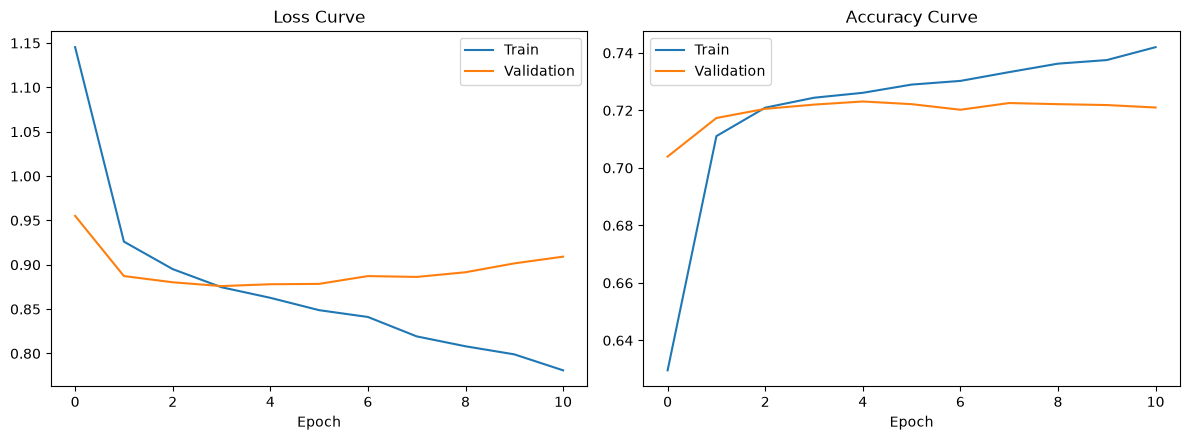

In [32]:
selected_history = accuracy_history if final_model is accuracy_model else soft_history
hist = pd.DataFrame(selected_history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(hist["loss"], label="Train")
axes[0].plot(hist["val_loss"], label="Validation")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist["accuracy"], label="Train")
axes[1].plot(hist["val_accuracy"], label="Validation")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

### **Model Chart 3 — Confusion matrix**

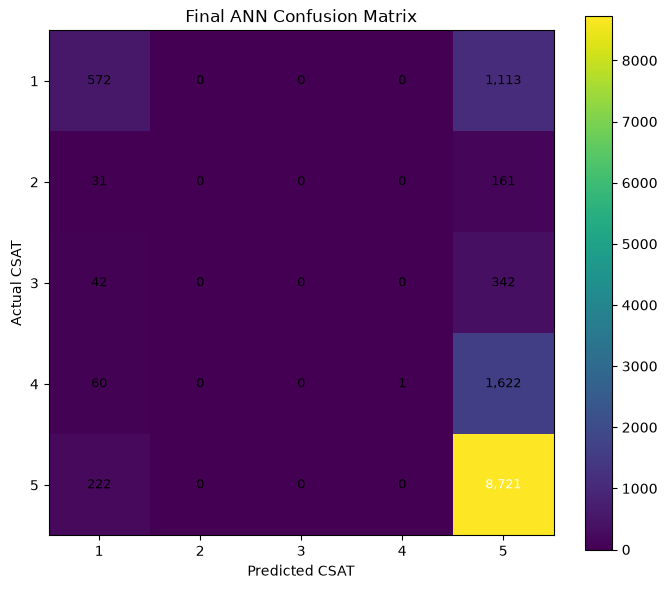

In [33]:
labels_idx = np.arange(num_classes)
cm = confusion_matrix(y_test, final_test_pred, labels=labels_idx)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)
ax.set_title("Final ANN Confusion Matrix")
ax.set_xlabel("Predicted CSAT")
ax.set_ylabel("Actual CSAT")
ax.set_xticks(labels_idx)
ax.set_yticks(labels_idx)
ax.set_xticklabels(label_encoder.classes_)
ax.set_yticklabels(label_encoder.classes_)

threshold = cm.max() * 0.55 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > threshold else "black", fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Classification report

In [34]:
target_names = [f"CSAT {x}" for x in label_encoder.classes_]
report = classification_report(
    y_test,
    final_test_pred,
    labels=labels_idx,
    target_names=target_names,
    zero_division=0,
    output_dict=True
)
report_df = pd.DataFrame(report).T
display(report_df.round(4))

,precision,recall,f1-score,support
CSAT 1,0.6170,0.3395,0.4380,"1,685.0000"
CSAT 2,0.0000,0.0000,0.0000,192.0000
CSAT 3,0.0000,0.0000,0.0000,384.0000
CSAT 4,1.0000,0.0006,0.0012,"1,683.0000"
CSAT 5,0.7292,0.9752,0.8345,"8,943.0000"
accuracy,0.7212,0.7212,0.7212,0.7212
macro avg,0.4693,0.2630,0.2547,"12,887.0000"
weighted avg,0.7173,0.7212,0.6365,"12,887.0000"


### **Model Chart 4 — Per-class precision and recall**

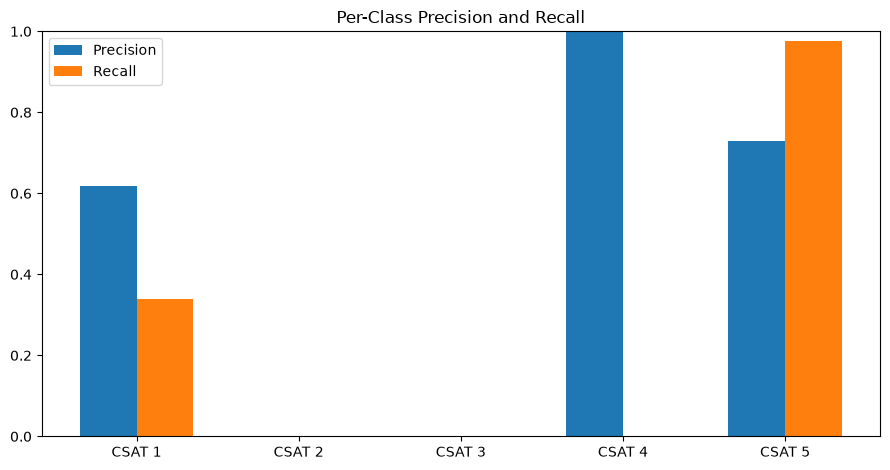

In [35]:
class_rows = [f"CSAT {x}" for x in label_encoder.classes_]
view = report_df.loc[class_rows, ["precision", "recall"]]

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(view))
w = 0.35
ax.bar(x - w/2, view["precision"], w, label="Precision")
ax.bar(x + w/2, view["recall"], w, label="Recall")
ax.set_xticks(x)
ax.set_xticklabels(class_rows)
ax.set_ylim(0, 1)
ax.set_title("Per-Class Precision and Recall")
ax.legend()
plt.tight_layout()
plt.show()

### **Model Chart 5 — Actual vs predicted CSAT distribution**

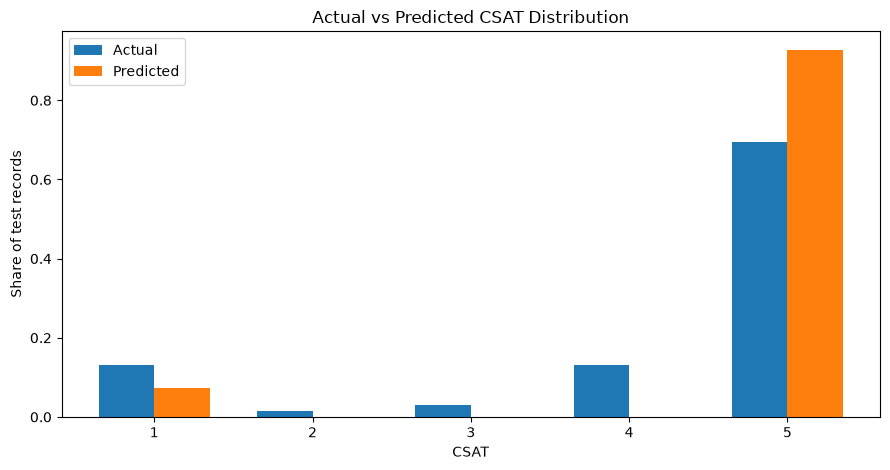

In [36]:
actual_scores = label_encoder.inverse_transform(y_test)
pred_scores = label_encoder.inverse_transform(final_test_pred)

actual_dist = pd.Series(actual_scores).value_counts(normalize=True).sort_index()
pred_dist = pd.Series(pred_scores).value_counts(normalize=True).sort_index()

scores = sorted(set(label_encoder.classes_))
actual_vals = [actual_dist.get(s, 0) for s in scores]
pred_vals = [pred_dist.get(s, 0) for s in scores]

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(scores))
w = 0.35
ax.bar(x - w/2, actual_vals, w, label="Actual")
ax.bar(x + w/2, pred_vals, w, label="Predicted")
ax.set_xticks(x)
ax.set_xticklabels(scores)
ax.set_title("Actual vs Predicted CSAT Distribution")
ax.set_xlabel("CSAT")
ax.set_ylabel("Share of test records")
ax.legend()
plt.tight_layout()
plt.show()

### **Model Chart 6 — Prediction error distance**

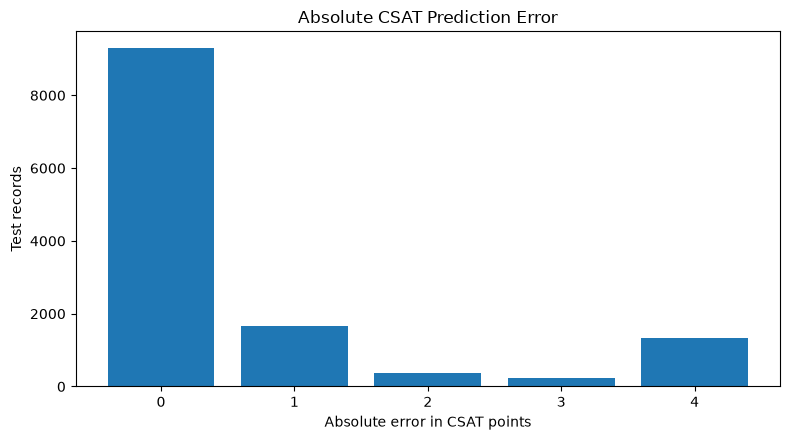

Exact-match accuracy: 0.7212
Within ±1 score: 0.8495


In [37]:
error_distance = np.abs(actual_scores - pred_scores)
err_counts = pd.Series(error_distance).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(err_counts.index.astype(str), err_counts.values)
ax.set_title("Absolute CSAT Prediction Error")
ax.set_xlabel("Absolute error in CSAT points")
ax.set_ylabel("Test records")
plt.tight_layout()
plt.show()

print("Exact-match accuracy:", round((error_distance == 0).mean(), 4))
print("Within ±1 score:", round((error_distance <= 1).mean(), 4))

## **11. Model Interpretability — Raw Feature Permutation Importance**

Permutation importance is calculated on a bounded test sample to keep the notebook practical.  
A larger accuracy drop means the feature carried more predictive information for the final ANN.

In [38]:
def raw_feature_permutation_importance(
    model, preprocessor, X_raw, y_true,
    feature_names, probability_divisor,
    sample_size=1200, seed=SEED
):
    rng = np.random.default_rng(seed)

    if len(X_raw) > sample_size:
        idx = rng.choice(len(X_raw), size=sample_size, replace=False)
        X_sample = X_raw.iloc[idx].copy().reset_index(drop=True)
        y_sample = np.asarray(y_true)[idx]
    else:
        X_sample = X_raw.copy().reset_index(drop=True)
        y_sample = np.asarray(y_true)

    base_X = preprocessor.transform(X_sample).astype(np.float32)
    base_probs = model.predict(base_X, verbose=0)
    if not np.allclose(probability_divisor, 1.0):
        base_probs = normalize_rows(base_probs / probability_divisor.reshape(1, -1))
    base_pred = base_probs.argmax(axis=1)
    base_acc = accuracy_score(y_sample, base_pred)

    rows = []
    for feature in feature_names:
        permuted = X_sample.copy()
        permuted[feature] = rng.permutation(permuted[feature].to_numpy())

        pX = preprocessor.transform(permuted).astype(np.float32)
        probs = model.predict(pX, verbose=0)
        if not np.allclose(probability_divisor, 1.0):
            probs = normalize_rows(probs / probability_divisor.reshape(1, -1))
        pred = probs.argmax(axis=1)

        perm_acc = accuracy_score(y_sample, pred)
        rows.append({
            "feature": feature,
            "accuracy_drop": base_acc - perm_acc
        })

    return pd.DataFrame(rows).sort_values("accuracy_drop", ascending=False), base_acc


importance_df, sampled_acc = raw_feature_permutation_importance(
    final_model,
    preprocessor,
    X_test,
    y_test,
    model_features,
    probability_divisor
)

print("Sample baseline accuracy:", round(sampled_acc, 4))
display(importance_df.head(15).round(4))

Sample baseline accuracy: 0.7325


,feature,accuracy_drop
28,customer_remarks,0.0350
15,order_date_time_missing,0.0050
2,response_time_minutes_log1p,0.0050
7,is_weekend,0.0033
8,remarks_length_log1p,0.0033
14,product_category_missing,0.0033
19,sub_category,0.0033
5,issue_hour_sin,0.0033
20,product_category,0.0033
13,customer_city_missing,0.0025


### **Model Chart 7 — Top raw feature importance**

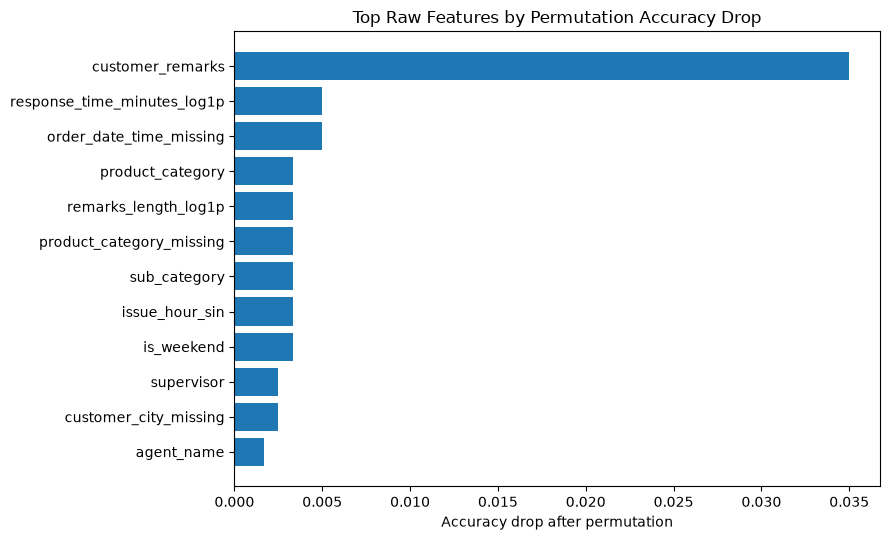

In [39]:
top_imp = importance_df.head(12).sort_values("accuracy_drop")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_imp["feature"], top_imp["accuracy_drop"])
ax.set_title("Top Raw Features by Permutation Accuracy Drop")
ax.set_xlabel("Accuracy drop after permutation")
plt.tight_layout()
plt.show()

## **12. Business Interpretation**

Use the outputs from the executed notebook to describe the final findings. Avoid hard-coding business conclusions before the notebook is run on the final dataset.

In [40]:
print("=== FINAL DATA-DRIVEN SUMMARY ===")
print("Overall mean CSAT:", round(df_feat["csat_score"].mean(), 3))
print("Final model:", best_candidate_name)
print("Final test accuracy:", round(final_test_metrics["Accuracy"], 4))
print("Majority baseline accuracy:", round(majority_metrics["Accuracy"], 4))
print("Macro F1:", round(final_test_metrics["Macro F1"], 4))
print("Quadratic Kappa:", round(final_test_metrics["Quadratic Kappa"], 4))
print("CSAT MAE:", round(final_test_metrics["CSAT MAE"], 4))
print("Within ±1:", round(final_test_metrics["Within ±1"], 4))

if "response_time_minutes" in df_feat.columns:
    valid = df_feat[["response_time_minutes", "csat_score"]].dropna()
    rho, p = spearmanr(valid["response_time_minutes"], valid["csat_score"])
    print("Response-time / CSAT Spearman rho:", round(rho, 4))

if "channel_name" in df_feat.columns:
    channel_summary = (
        df_feat.groupby("channel_name")["csat_score"]
        .agg(["mean", "count"])
        .query("count >= 100")
        .sort_values("mean")
    )
    if len(channel_summary):
        print("Lowest sufficiently represented channel:", channel_summary.index[0],
              "| mean CSAT:", round(channel_summary.iloc[0]["mean"], 3))

=== FINAL DATA-DRIVEN SUMMARY ===
Overall mean CSAT: 4.242
Final model: Accuracy ANN
Final test accuracy: 0.7212
Majority baseline accuracy: 0.694
Macro F1: 0.2547
Quadratic Kappa: 0.3546
CSAT MAE: 0.6537
Within ±1: 0.8495
Response-time / CSAT Spearman rho: -0.182
Lowest sufficiently represented channel: Email | mean CSAT: 3.899


### Operational use

The model can be used as an early-warning layer for customer-support interactions. Low predicted CSAT can trigger case review, supervisor attention, follow-up communication or root-cause analysis. The EDA and permutation-importance sections should be used to explain **why** particular operational factors deserve attention, rather than presenting the ANN as a black box.

## **13. Save Final ANN and Deployment Artifacts**

In [41]:
ARTIFACT_DIR = Path("csat_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

MODEL_PATH = ARTIFACT_DIR / "csat_ann.keras"
PREPROCESSOR_PATH = ARTIFACT_DIR / "preprocessor.pkl"
LABEL_ENCODER_PATH = ARTIFACT_DIR / "label_encoder.pkl"
CONFIG_PATH = ARTIFACT_DIR / "feature_config.json"
DECISION_PATH = ARTIFACT_DIR / "decision_config.json"

final_model.save(MODEL_PATH)
joblib.dump(preprocessor, PREPROCESSOR_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)

feature_config = {
    "project": "E-Commerce Customer Satisfaction Score Prediction",
    "model_type": "Artificial Neural Network - Multiclass Classification",
    "target": "csat_score",
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "text_feature": text_feature,
    "model_features": model_features,
    "classes": [int(x) for x in label_encoder.classes_],
    "selected_validation_candidate": best_candidate_name
}

decision_config = {
    "prediction_rule": (
        "argmax" if np.allclose(probability_divisor, 1.0)
        else "divide_probabilities_by_class_divisor_then_argmax"
    ),
    "probability_divisor": probability_divisor.astype(float).tolist()
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(feature_config, f, indent=2)

with open(DECISION_PATH, "w", encoding="utf-8") as f:
    json.dump(decision_config, f, indent=2)

print("Saved:")
for p in [MODEL_PATH, PREPROCESSOR_PATH, LABEL_ENCODER_PATH, CONFIG_PATH, DECISION_PATH]:
    print(" -", p)

Saved:
 - csat_artifacts\csat_ann.keras
 - csat_artifacts\preprocessor.pkl
 - csat_artifacts\label_encoder.pkl
 - csat_artifacts\feature_config.json
 - csat_artifacts\decision_config.json


### Reload artifacts and sanity-check predictions

In [42]:
loaded_model = keras.models.load_model(MODEL_PATH)
loaded_preprocessor = joblib.load(PREPROCESSOR_PATH)
loaded_encoder = joblib.load(LABEL_ENCODER_PATH)

with open(DECISION_PATH, "r", encoding="utf-8") as f:
    loaded_decision = json.load(f)

sample_raw = X_test.head(5).copy()
sample_p = loaded_preprocessor.transform(sample_raw).astype(np.float32)
sample_probs = loaded_model.predict(sample_p, verbose=0)

divisor = np.array(loaded_decision["probability_divisor"], dtype=np.float32)
if not np.allclose(divisor, 1.0):
    sample_probs = normalize_rows(sample_probs / divisor.reshape(1, -1))

sample_pred_idx = sample_probs.argmax(axis=1)

sanity = pd.DataFrame({
    "actual_csat": loaded_encoder.inverse_transform(y_test[:len(sample_raw)]),
    "predicted_csat": loaded_encoder.inverse_transform(sample_pred_idx),
    "confidence": sample_probs.max(axis=1)
})
display(sanity.round(4))

,actual_csat,predicted_csat,confidence
0,2,5,0.6511
1,1,5,0.6520
2,5,5,0.9364
3,5,5,0.9161
4,5,5,0.3888


### Package artifacts for Flask

In [43]:
import shutil
zip_path = shutil.make_archive("csat_artifacts", "zip", ARTIFACT_DIR)
print("Created:", zip_path)

Created: c:\Users\pkjos\OneDrive\Desktop\deepcsat__score_prediction\csat_artifacts.zip


## **14. Flask Deployment Contract**

The Flask application should:

1. collect the same raw business inputs used by this notebook;
2. normalize input column names;
3. run the same `build_features()` logic;
4. select `model_features` in the saved order;
5. call `preprocessor.transform(...)`;
6. call `csat_ann.keras`;
7. apply the saved `decision_config.json` probability correction if required;
8. map the predicted class back to CSAT 1–5 with `label_encoder.pkl`.

**Do not retrain the ANN inside Flask.**

## **15. Final Submission Checklist**

- [ ] Run the entire notebook from top to bottom without errors.
- [ ] Confirm the final ANN beats or appropriately contextualizes the majority-class baseline.
- [ ] Replace the GitHub placeholder with the final repository URL.
- [ ] Save the notebook with final outputs visible.
- [ ] Keep `csat_artifacts/` for the Flask demo.
- [ ] Build `app.py` + `templates/index.html`.
- [ ] Test several Flask inputs against notebook predictions.
- [ ] Record the 15–25 minute explanation video.
- [ ] Make the Colab/Drive submission viewable.

# **Conclusion**

This revised notebook prioritizes a defensible improvement in prediction accuracy rather than forcing the ANN to treat every CSAT class as equally frequent. It keeps the original business objective, reduces repetitive EDA, prevents test-set model selection, strengthens the text and agent-related features, and explicitly compares the final ANN with a majority-class benchmark. Final claims should be based only on the metrics produced when this notebook is executed on the submitted dataset.